In [ ]:
# In the name of GOD, the Most Gracious, the Most Merciful

In [1]:
import json
# import ijson
# import pandas as pd
# from pandas import json_normalize
import numpy as np
import matplotlib.pyplot as plt
# from mpl_toolkits import mplot3d 
# import matplotlib.tri as mtri
# import plotly.express as px
# import plotly.io as pio
# import plotly.graph_objects as go 
# import os
# from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# from imblearn.metrics import geometric_mean_score
# import warnings
# from sklearn.exceptions import UndefinedMetricWarning
# from sklearn.metrics import cohen_kappa_score
# import scipy.stats as stats
# import statistics

# from skcriteria import Data, MIN, MAX
# from skcriteria.madm import closeness, simple

In [ ]:
# pip install pingouin

In [2]:
import pingouin as pg

C:\Users\fatem\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\fatem\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
import pandas as pd

In [4]:
from matplotlib.lines import Line2D

In [5]:
from matplotlib.patches import Patch

In [ ]:
# import math

In [ ]:
# import copy

In [ ]:
# from scipy import stats

In [ ]:
# pd.set_option('display.max_rows', None)

In [ ]:
# plt.get_backend()

In [ ]:
# L2DHF, UNSW, 12PCA, Poisson, RevisedEDis, Updated

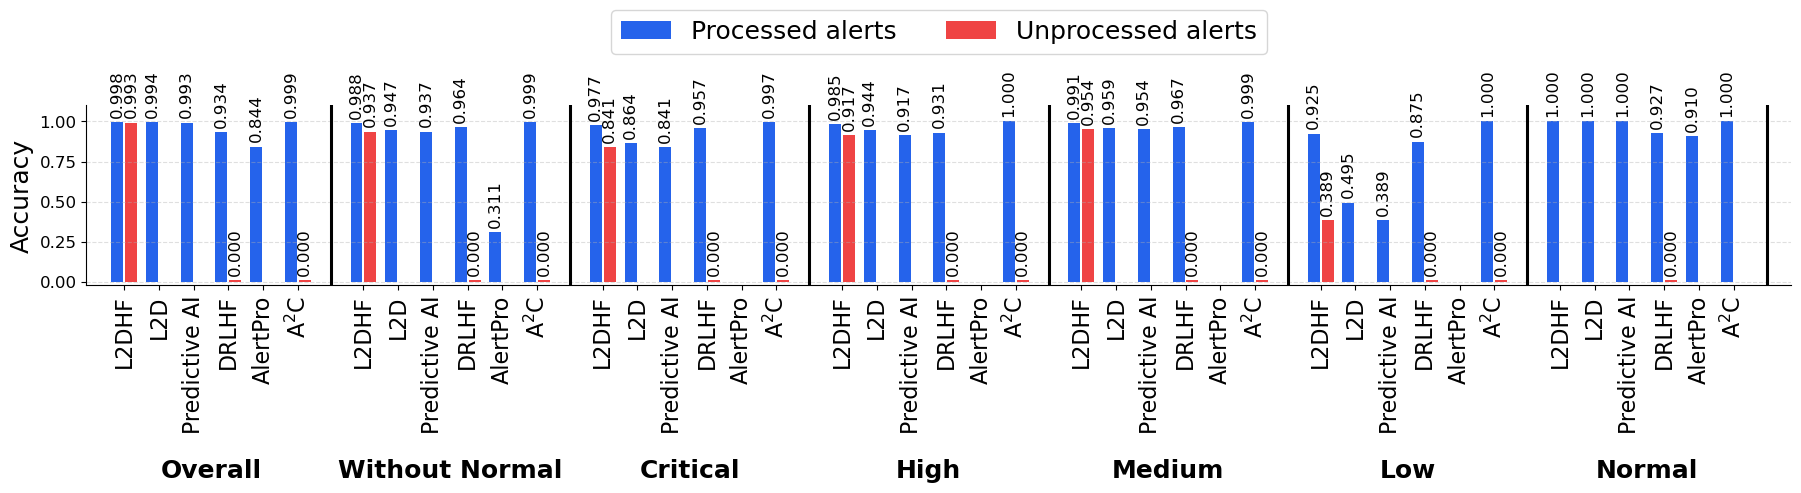

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt

# ==========================
# Data
# ==========================

categories = [
    "Overall",
    "Without Normal",
    "Critical",
    "High",
    "Medium",
    "Low",
    "Normal"
]

models = [
    "L2DHF",
    "L2D",
    "Predictive AI",
    "DRLHF",
    "AlertPro",
    r"A$^2$C"
]

processed = {
    "Overall":        [0.998, 0.994, 0.993, 0.934, 0.844, 0.999],
    "Without Normal": [0.988, 0.947, 0.937, 0.964, 0.311, 0.999],
    "Critical":       [0.977, 0.864, 0.841, 0.957, None, 0.997],
    "High":           [0.985, 0.944, 0.917, 0.931, None, 1.000],
    "Medium":         [0.991, 0.959, 0.954, 0.967, None, 0.999],
    "Low":            [0.925, 0.495, 0.389, 0.875, None, 1.000],
    "Normal":         [1.000, 1.000, 1.000, 0.927, 0.910, 1.000]
}

unprocessed = {
    "Overall":        [0.993, None, None, 0.0, None, 0.0],
    "Without Normal": [0.937, None, None, 0.0, None, 0.0],
    "Critical":       [0.841, None, None, 0.0, None, 0.0],
    "High":           [0.917, None, None, 0.0, None, 0.0],
    "Medium":         [0.954, None, None, 0.0, None, 0.0],
    "Low":            [0.389, None, None, 0.0, None, 0.0],
    "Normal":         [None, None, None, 0.0, None, None]
}

# ==========================
# Plot settings (FIXED)
# ==========================

fig, ax = plt.subplots(figsize=(22, 3))

# bar_width = 1.3         # 🔥 thicker bars (was 0.30)
model_spacing = 4.5      # 🔥 more space between models
group_spacing = 4       # 🔥 more space between categories

xticks = []
xticklabels = []
group_centers = []

current_x = 1

# helper for tiny bars when value is 0.0
def safe_height(v):
    if v == 0.0:
        return 0.014  # tiny visible bar
    return v

# ==========================
# Draw bars
# ==========================

pair_offset = 0.9     # distance from centre
bar_width = 1.3         # thick bars

for category in categories:

    start_group = current_x

    for i, model in enumerate(models):

        proc = processed[category][i]
        unproc = unprocessed[category][i]

        center = current_x

        blue_x = center - pair_offset
        red_x  = center + pair_offset

        if proc is not None:

            h = safe_height(proc)

            ax.bar(
                blue_x,
                h,
                width=bar_width+0.25,
                color='#2563EB',
                align='center',
                label='Processed alerts'
                if (category == categories[0] and i == 0)
                else ""
            )

            ax.text(
                blue_x,
                h + 0.045,
                f"{proc:.3f}",
                ha='center',
                rotation=90,
                fontsize=12
            )

        if unproc is not None:

            h = safe_height(unproc)

            ax.bar(
                red_x,
                h,
                width=bar_width+0.25,
                color='#EF4444',
                align='center',
                label='Unprocessed alerts'
                if (category == categories[0] and i == 0)
                else ""
            )

            ax.text(
                red_x,
                h + 0.045,
                f"{unproc:.3f}",
                ha='center',
                rotation=90,
                fontsize=12
            )

        xticks.append(center)
        xticklabels.append(model)

        current_x += model_spacing
        
    end_group = current_x - model_spacing
    group_centers.append((start_group + end_group) / 2)

    # separator line
    ax.axvline(
        current_x - model_spacing/20,
        color='black',
        linestyle='-',
        alpha=1,
        linewidth = 2.2
    )

    current_x += group_spacing

# ==========================
# X axis (MODEL LABELS)
# ==========================

ax.set_xticks(xticks)
ax.set_xticklabels(
    xticklabels,
    rotation=90,   # 🔥 FIX: no rotation = no overlap
    ha='center',
    fontsize=16
)

# ==========================
# CATEGORY LABELS (CENTERED)
# ==========================

for center, category in zip(group_centers, categories):
    ax.text(
        center,
        -1.1,
        category,
        ha='center',
        va='top',
        fontsize=18,
        fontweight='bold'
    )

# ==========================
# Formatting
# ==========================

ax.set_ylabel("Accuracy", fontsize=18)
ax.set_ylim(-0.02, 1.1)
ax.tick_params(axis='y', labelsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.4)

# 🔥 FIX: legend outside plot (no overlap)
ax.legend(
    fontsize=18,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.6),
    ncol=2
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(bottom=0.20, top=0.80)
ax.margins(x=0.015)
# plt.savefig("Accuracy_all_UNSW.pdf", bbox_inches='tight')
plt.show()

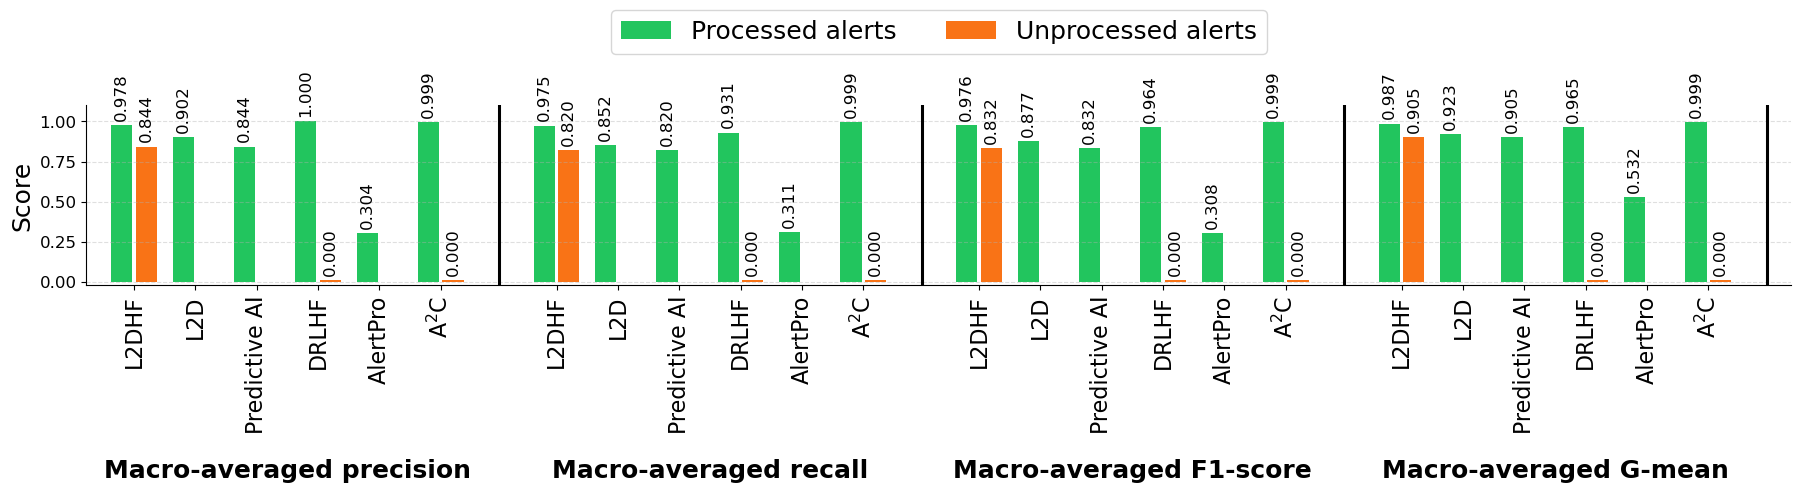

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt

# ==========================
# Data
# ==========================

categories = [
    "Macro-averaged precision",
    "Macro-averaged recall",
    "Macro-averaged F1-score",
    "Macro-averaged G-mean"
]

models = [
    "L2DHF",
    "L2D",
    "Predictive AI",
    "DRLHF",
    "AlertPro",
    r"A$^2$C"
]

processed = {
    "Macro-averaged precision":[0.978, 0.902, 0.844, 1.0, 0.304, 0.999],
    "Macro-averaged recall":[0.975, 0.852, 0.820, 0.931, 0.311, 0.999],
    "Macro-averaged F1-score":[0.976, 0.877, 0.832, 0.964, 0.308, 0.999],
    "Macro-averaged G-mean":[0.987, 0.923, 0.905, 0.965, 0.532, 0.999]
}

unprocessed = {
    "Macro-averaged precision":[0.844, None, None, 0.0, None, 0.0],
    "Macro-averaged recall": [0.820, None, None, 0.0, None, 0.0],
    "Macro-averaged F1-score":[0.832, None, None, 0.0, None, 0.0],
    "Macro-averaged G-mean":[0.905, None, None, 0.0, None, 0.0]
}

# ==========================
# Plot settings (FIXED)
# ==========================

fig, ax = plt.subplots(figsize=(22, 3))

# bar_width = 1.3         # 🔥 thicker bars (was 0.30)
model_spacing = 4.5      # 🔥 more space between models
group_spacing = 4       # 🔥 more space between categories

xticks = []
xticklabels = []
group_centers = []

current_x = 1

# helper for tiny bars when value is 0.0
def safe_height(v):
    if v == 0.0:
        return 0.014  # tiny visible bar
    return v

# ==========================
# Draw bars
# ==========================

pair_offset = 0.9     # distance from centre
bar_width = 1.3         # thick bars

for category in categories:

    start_group = current_x

    for i, model in enumerate(models):

        proc = processed[category][i]
        unproc = unprocessed[category][i]

        center = current_x

        blue_x = center - pair_offset
        red_x  = center + pair_offset

        if proc is not None:

            h = safe_height(proc)

            ax.bar(
                blue_x,
                h,
                width=bar_width+0.25,
                color='#22C55E',
                align='center',
                label='Processed alerts'
                if (category == categories[0] and i == 0)
                else ""
            )

            ax.text(
                blue_x,
                h + 0.045,
                f"{proc:.3f}",
                ha='center',
                rotation=90,
                fontsize=12
            )

        if unproc is not None:

            h = safe_height(unproc)

            ax.bar(
                red_x,
                h,
                width=bar_width+0.25,
                color='#F97316',
                align='center',
                label='Unprocessed alerts'
                if (category == categories[0] and i == 0)
                else ""
            )

            ax.text(
                red_x,
                h + 0.045,
                f"{unproc:.3f}",
                ha='center',
                rotation=90,
                fontsize=12
            )

        xticks.append(center)
        xticklabels.append(model)

        current_x += model_spacing
        
    end_group = current_x - model_spacing
    group_centers.append((start_group + end_group) / 2)

    # separator line
    ax.axvline(
        current_x - model_spacing/20,
        color='black',
        linestyle='-',
        alpha=1,
        linewidth = 2.2
    )

    current_x += group_spacing

# ==========================
# X axis (MODEL LABELS)
# ==========================

ax.set_xticks(xticks)
ax.set_xticklabels(
    xticklabels,
    rotation=90,   # 🔥 FIX: no rotation = no overlap
    ha='center',
    fontsize=16
)

# ==========================
# CATEGORY LABELS (CENTERED)
# ==========================

for center, category in zip(group_centers, categories):
    ax.text(
        center,
        -1.1,
        category,
        ha='center',
        va='top',
        fontsize=18,
        fontweight='bold'
    )

# ==========================
# Formatting
# ==========================

ax.set_ylabel("Score", fontsize=18)
ax.set_ylim(-0.02, 1.1)
ax.tick_params(axis='y', labelsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.4)

# 🔥 FIX: legend outside plot (no overlap)
ax.legend(
    fontsize=18,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.6),
    ncol=2
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(bottom=0.20, top=0.80)
ax.margins(x=0.015)
# plt.savefig("Other_metrics_all_UNSW.pdf", bbox_inches='tight')
plt.show()

In [8]:
# Effect_size
def Effect_size(x, y):
    # remove None values
    x = [d for d in x if d is not None]
    y = [d for d in y if d is not None]
    
    # convert to nparray 
    x = np.asarray(x)
    y = np.asarray(y)
    
    effect_size = pg.mwu(x=x, y=y, alternative='two-sided')['RBC'].iloc[0]
    
    return effect_size

In [9]:
# Bootstrap CI
def Confidence_Interval(x, y):
    # remove None values
    x = [d for d in x if d is not None]
    y = [d for d in y if d is not None]
    
    # convert to nparray 
    x = np.asarray(x)
    y = np.asarray(y)
    
    ci = pg.compute_bootci(x, y, func=Effect_size, n_boot=2000, seed=42)
    
    return ci



In [10]:
def mwu_stats(x, y):
    
    # remove None values
    x = [d for d in x if d is not None]
    y = [d for d in y if d is not None]
    
    # remove None values
    x = np.asarray(x)
    y = np.asarray(y)


    res = pg.mwu(x=x, y=y, alternative='two-sided')

    return {
        'U_val': res['U_val'].iloc[0],
        'p_val': res['p_val'].iloc[0],
        'RBC': res['RBC'].iloc[0],
        'CLES': res['CLES'].iloc[0]
        
    }

In [ ]:
# Accuracy, P-value, Effect_size and Conficence_Interval

In [ ]:
with open('accuracy_data_L2DHF_UNSW_12PCA.json', 'r') as file:
    accuracy_data_L2DHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in accuracy_data_L2DHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('accuracy_data_DRLHF_UNSW_12PCA.json', 'r') as file:
    accuracy_data_DRLHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in accuracy_data_DRLHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('accuracy_data_L2D_UNSW.json', 'r') as file:
    accuracy_data_L2D_UNSW = json.load(file)

In [ ]:
for key in accuracy_data_L2D_UNSW.keys():
    print(key)

In [ ]:
with open('accuracy_data_Ensemble_UNSW.json', 'r') as file:
    accuracy_data_Ensemble_UNSW = json.load(file)

In [ ]:
for key in accuracy_data_Ensemble_UNSW.keys():
    print(key)

In [ ]:
with open('accuracy_data_A2C_TimeModified_UNSW.json', 'r') as file:
    accuracy_data_A2C_TimeModified_UNSW = json.load(file)

In [ ]:
for key in accuracy_data_A2C_TimeModified_UNSW.keys():
    print(key)

In [ ]:
with open('accuracy_data_Active_Learning_UNSW.json', 'r') as file:
    accuracy_data_Active_Learning_UNSW = json.load(file)

In [ ]:
for key in accuracy_data_Active_Learning_UNSW.keys():
    print(key)

In [ ]:
## Overall Acuuracy

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For accuracy, which is a benefit metric (the higher, the better):
# x: L2DHF
# y: model (baselines, SOTA)

In [ ]:
# Calculate P_value, effect_size, confidence intervals of models versus L2DHF
accuracy_results = []

models = {
    "DRLHF": accuracy_data_DRLHF_UNSW_12PCA,
    "L2D": accuracy_data_L2D_UNSW,
    "Ensemble": accuracy_data_Ensemble_UNSW,
    "A2C": accuracy_data_A2C_TimeModified_UNSW,
    "Active Learning": accuracy_data_Active_Learning_UNSW
}

categories = [
    "overall",
    "critical",
    "high",
    "medium",
    "low",
    "normal",
    "without_normal"
]

for model_name, model_dict in models.items():

    for category in categories:

        # Find the corresponding L2DHF key
        l2dhf_key = next(
            (
                key
                for key in accuracy_data_L2DHF_UNSW_12PCA.keys()
                if f"accuracy_{category}_" in key
            ),
            None
        )

        # Find the corresponding key in the comparison model
        model_key = next(
            (
                key
                for key in model_dict.keys()
                if f"accuracy_{category}_" in key
            ),
            None
        )

        # Skip categories not available in either dictionary
        if l2dhf_key is None or model_key is None:
            continue

        x = accuracy_data_L2DHF_UNSW_12PCA[l2dhf_key]
        y = model_dict[model_key]

        stats = mwu_stats(x, y)

        P_value = stats['p_val']
        Effect_size_point = stats['RBC']

        CI_value = Confidence_Interval(x, y)

        accuracy_results.append({
            "Model": model_name,
            "Category": category,
            "P_value_accuracy": P_value,
            "Effect_size_accuracy": Effect_size_point,
            "CI_Lower_accuracy": CI_value[0],
            "CI_Upper_accuracy": CI_value[1]
        })

accuracy_results_df = pd.DataFrame(accuracy_results)



In [ ]:
print(accuracy_results_df)

In [ ]:
accuracy_results_df.to_json(
    'accuracy_statistic_results_UNSW.json',
    orient='records',
    indent=4
)

In [ ]:
# Uploading precision data

In [ ]:
with open('Precision_data_L2DHF_UNSW_12PCA.json', 'r') as file:
    Precision_data_L2DHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in Precision_data_L2DHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('Precision_data_DRLHF_UNSW_12PCA.json', 'r') as file:
    Precision_data_DRLHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in Precision_data_DRLHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('Precision_data_L2D_UNSW.json', 'r') as file:
    Precision_data_L2D_UNSW = json.load(file)

In [ ]:
for key in Precision_data_L2D_UNSW.keys():
    print(key)

In [ ]:
with open('Precision_data_PredictiveAI_UNSW.json', 'r') as file:
    Precision_data_PredictiveAI_UNSW = json.load(file)

In [ ]:
for key in Precision_data_PredictiveAI_UNSW.keys():
    print(key)

In [ ]:
with open('Precision_data_A2C_TimeModified_UNSW.json', 'r') as file:
    Precision_data_A2C_TimeModified_UNSW = json.load(file)

In [ ]:
for key in Precision_data_A2C_TimeModified_UNSW.keys():
    print(key)

In [ ]:
with open('All_metric_data_Active_Learning_UNSW.json', 'r') as file:
    All_metric_data_Active_Learning_UNSW = json.load(file)

In [ ]:
for key in All_metric_data_Active_Learning_UNSW.keys():
    print(key)

In [ ]:
# Precision related calculations
# Calculate P_value, effect_size, confidence intervals of models versus L2DHF
Precision_results = []

models = {
    "DRLHF": Precision_data_DRLHF_UNSW_12PCA,
    "L2D": Precision_data_L2D_UNSW,
    "Ensemble": Precision_data_PredictiveAI_UNSW,
    "A2C": Precision_data_A2C_TimeModified_UNSW,
    "Active Learning": All_metric_data_Active_Learning_UNSW
}

categories = [
    "Overall"
]

for model_name, model_dict in models.items():

    for category in categories:

        # Find the corresponding L2DHF key
        l2dhf_key = next(
            (
                key
                for key in Precision_data_L2DHF_UNSW_12PCA.keys()
                if f"Precision_{category}_" in key
            ),
            None
        )

        # Find the corresponding key in the comparison model
        model_key = next(
            (
                key
                for key in model_dict.keys()
                if f"Precision_{category}_" in key
            ),
            None
        )

        # Skip categories not available in either dictionary
        if l2dhf_key is None or model_key is None:
            continue

        x = Precision_data_L2DHF_UNSW_12PCA[l2dhf_key]
        y = model_dict[model_key]

        stats = mwu_stats(x, y)

        P_value = stats['p_val']
        Effect_size_point = stats['RBC']

        CI_value = Confidence_Interval(x, y)

        Precision_results.append({
            "Model": model_name,
            "Category": category,
            "P_value_Precision": P_value,
            "Effect_size_Precision": Effect_size_point,
            "CI_Lower_Precision": CI_value[0],
            "CI_Upper_Precision": CI_value[1]
        })

Precision_results_df = pd.DataFrame(Precision_results)


In [ ]:
print(Precision_results_df)

In [ ]:
Precision_results_df.to_json(
    'Precision_statistic_results_UNSW.json',
    orient='records',
    indent=4
)

In [ ]:
# Uploading recall data

In [ ]:
with open('Recall_data_L2DHF_UNSW_12PCA.json', 'r') as file:
    Recall_data_L2DHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in Recall_data_L2DHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('Recall_data_DRLHF_UNSW_12PCA.json', 'r') as file:
    Recall_data_DRLHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in Recall_data_DRLHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('Recall_data_L2D_UNSW.json', 'r') as file:
    Recall_data_L2D_UNSW = json.load(file)

In [ ]:
for key in Recall_data_L2D_UNSW.keys():
    print(key)

In [ ]:
with open('Recall_data_PredictiveAI_UNSW.json', 'r') as file:
    Recall_data_PredictiveAI_UNSW = json.load(file)

In [ ]:
for key in Recall_data_PredictiveAI_UNSW.keys():
    print(key)

In [ ]:
with open('Recall_data_A2C_TimeModified_UNSW.json', 'r') as file:
    Recall_data_A2C_TimeModified_UNSW = json.load(file)

In [ ]:
for key in Recall_data_A2C_TimeModified_UNSW.keys():
    print(key)

In [ ]:
# Recall related calculations
# Calculate P_value, effect_size, confidence intervals of models versus L2DHF
Recall_results = []

models = {
    "DRLHF": Recall_data_DRLHF_UNSW_12PCA,
    "L2D": Recall_data_L2D_UNSW,
    "Ensemble": Recall_data_PredictiveAI_UNSW,
    "A2C": Recall_data_A2C_TimeModified_UNSW,
    "Active Learning": All_metric_data_Active_Learning_UNSW
}

categories = [
    "Overall"
]

for model_name, model_dict in models.items():

    for category in categories:

        # Find the corresponding L2DHF key
        l2dhf_key = next(
            (
                key
                for key in Recall_data_L2DHF_UNSW_12PCA.keys()
                if f"Recall_{category}_" in key
            ),
            None
        )

        # Find the corresponding key in the comparison model
        model_key = next(
            (
                key
                for key in model_dict.keys()
                if f"Recall_{category}_" in key
            ),
            None
        )

        # Skip categories not available in either dictionary
        if l2dhf_key is None or model_key is None:
            continue

        x = Recall_data_L2DHF_UNSW_12PCA[l2dhf_key]
        y = model_dict[model_key]

        stats = mwu_stats(x, y)

        P_value = stats['p_val']
        Effect_size_point = stats['RBC']

        CI_value = Confidence_Interval(x, y)

        Recall_results.append({
            "Model": model_name,
            "Category": category,
            "P_value_Recall": P_value,
            "Effect_size_Recall": Effect_size_point,
            "CI_Lower_Recall": CI_value[0],
            "CI_Upper_Recall": CI_value[1]
        })

Recall_results_df = pd.DataFrame(Recall_results)


In [ ]:
print(Recall_results_df)

In [ ]:
Recall_results_df.to_json(
    'Recall_statistic_results_UNSW.json',
    orient='records',
    indent=4
)

In [ ]:
# Uploading F1_score data

In [ ]:
with open('F1_score_data_L2DHF_UNSW_12PCA.json', 'r') as file:
    F1_score_data_L2DHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in F1_score_data_L2DHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('F1_score_data_DRLHF_UNSW_12PCA.json', 'r') as file:
    F1_score_data_DRLHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in F1_score_data_DRLHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('F1_score_data_L2D_UNSW.json', 'r') as file:
    F1_score_data_L2D_UNSW = json.load(file)

In [ ]:
for key in F1_score_data_L2D_UNSW.keys():
    print(key)

In [ ]:
with open('F1_score_data_PredictiveAI_UNSW.json', 'r') as file:
    F1_score_data_PredictiveAI_UNSW = json.load(file)

In [ ]:
for key in F1_score_data_PredictiveAI_UNSW.keys():
    print(key)

In [ ]:
with open('F1_score_data_A2C_TimeModified_UNSW.json', 'r') as file:
    F1_score_data_A2C_TimeModified_UNSW = json.load(file)

In [ ]:
for key in F1_score_data_A2C_TimeModified_UNSW.keys():
    print(key)

In [ ]:
# F1_score related calculations
# Calculate P_value, effect_size, confidence intervals of models versus L2DHF
F1_score_results = []

models = {
    "DRLHF": F1_score_data_DRLHF_UNSW_12PCA,
    "L2D": F1_score_data_L2D_UNSW,
    "Ensemble": F1_score_data_PredictiveAI_UNSW,
    "A2C": F1_score_data_A2C_TimeModified_UNSW,
    "Active Learning": All_metric_data_Active_Learning_UNSW
}

categories = [
    "Overall"
]

for model_name, model_dict in models.items():

    for category in categories:

        # Find the corresponding L2DHF key
        l2dhf_key = next(
            (
                key
                for key in F1_score_data_L2DHF_UNSW_12PCA.keys()
                if f"F1_Score_{category}_" in key
            ),
            None
        )

        # Find the corresponding key in the comparison model
        model_key = next(
            (
                key
                for key in model_dict.keys()
                if f"F1_Score_{category}_" in key
            ),
            None
        )

        # Skip categories not available in either dictionary
        if l2dhf_key is None or model_key is None:
            continue

        x = F1_score_data_L2DHF_UNSW_12PCA[l2dhf_key]
        y = model_dict[model_key]

        stats = mwu_stats(x, y)

        P_value = stats['p_val']
        Effect_size_point = stats['RBC']

        CI_value = Confidence_Interval(x, y)

        F1_score_results.append({
            "Model": model_name,
            "Category": category,
            "P_value_F1_score": P_value,
            "Effect_size_F1_score": Effect_size_point,
            "CI_Lower_F1_score": CI_value[0],
            "CI_Upper_F1_score": CI_value[1]
        })

F1_score_results_df = pd.DataFrame(F1_score_results)


In [ ]:
print(F1_score_results_df)

In [ ]:
F1_score_results_df.to_json(
    'F1_score_statistic_results_UNSW.json',
    orient='records',
    indent=4
)

In [ ]:
# Uploading G_mean data

In [ ]:
with open('G_mean_data_L2DHF_UNSW_12PCA.json', 'r') as file:
    G_mean_data_L2DHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in G_mean_data_L2DHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('G_mean_data_DRLHF_UNSW_12PCA.json', 'r') as file:
    G_mean_data_DRLHF_UNSW_12PCA = json.load(file)

In [ ]:
for key in G_mean_data_DRLHF_UNSW_12PCA.keys():
    print(key)

In [ ]:
with open('G_mean_data_L2D_UNSW.json', 'r') as file:
    G_mean_data_L2D_UNSW = json.load(file)

In [ ]:
for key in G_mean_data_L2D_UNSW.keys():
    print(key)

In [ ]:
with open('G_mean_data_PredictiveAI_UNSW.json', 'r') as file:
    G_mean_data_PredictiveAI_UNSW = json.load(file)

In [ ]:
for key in G_mean_data_PredictiveAI_UNSW.keys():
    print(key)

In [ ]:
with open('G_mean_data_A2C_TimeModified_UNSW.json', 'r') as file:
    G_mean_data_A2C_TimeModified_UNSW = json.load(file)

In [ ]:
for key in G_mean_data_A2C_TimeModified_UNSW.keys():
    print(key)

In [ ]:
# G_mean related calculations
# Calculate P_value, effect_size, confidence intervals of models versus L2DHF
G_mean_results = []

models = {
    "DRLHF": G_mean_data_DRLHF_UNSW_12PCA,
    "L2D": G_mean_data_L2D_UNSW,
    "Ensemble": G_mean_data_PredictiveAI_UNSW,
    "A2C": G_mean_data_A2C_TimeModified_UNSW,
    "Active Learning": All_metric_data_Active_Learning_UNSW
}

categories = [
    "Overall"
]

for model_name, model_dict in models.items():

    for category in categories:

        # Find the corresponding L2DHF key
        l2dhf_key = next(
            (
                key
                for key in G_mean_data_L2DHF_UNSW_12PCA.keys()
                if f"G_mean_{category}_" in key
            ),
            None
        )

        # Find the corresponding key in the comparison model
        model_key = next(
            (
                key
                for key in model_dict.keys()
                if f"G_mean_{category}_" in key
            ),
            None
        )

        # Skip categories not available in either dictionary
        if l2dhf_key is None or model_key is None:
            continue

        x = G_mean_data_L2DHF_UNSW_12PCA[l2dhf_key]
        y = model_dict[model_key]

        stats = mwu_stats(x, y)

        P_value = stats['p_val']
        Effect_size_point = stats['RBC']

        CI_value = Confidence_Interval(x, y)

        G_mean_results.append({
            "Model": model_name,
            "Category": category,
            "P_value_G_mean": P_value,
            "Effect_size_G_mean": Effect_size_point,
            "CI_Lower_G_mean": CI_value[0],
            "CI_Upper_G_mean": CI_value[1]
        })

G_mean_results_df = pd.DataFrame(G_mean_results)


In [ ]:
print(G_mean_results_df)

In [ ]:
G_mean_results_df.to_json(
    'G_mean_statistic_results_UNSW.json',
    orient='records',
    indent=4
)

In [ ]:
# Unprocessed alerts, Deferred alerts 

In [ ]:
# Uploading unprocessed alerts

In [11]:
with open('all_Analyst_workload_A2C_UNSW.json', 'r') as file:
    all_Analyst_workload_A2C_UNSW = json.load(file)

In [12]:
with open('all_Analyst_workload_DRLHF_12PCA_UNSW.json', 'r') as file:
    all_Analyst_workload_DRLHF_12PCA_UNSW = json.load(file)

In [13]:
with open('all_Analyst_workload_L2D_UNSW.json', 'r') as file:
    all_Analyst_workload_L2D_UNSW = json.load(file)

In [14]:
with open('all_Analyst_workload_L2DHF_12PCA_UNSW.json', 'r') as file:
    all_Analyst_workload_L2DHF_12PCA_UNSW = json.load(file)

In [ ]:
# Uploading deferred alerts

In [15]:
with open('deferred_alerts_to_analyst_A2C_UNSW.json', 'r') as file:
    deferred_alerts_to_analyst_A2C_UNSW = json.load(file)

In [16]:
with open('deferred_alerts_to_analyst_DRLHF_12PCA_UNSW.json', 'r') as file:
    deferred_alerts_to_analyst_DRLHF_12PCA_UNSW = json.load(file)

In [17]:
with open('deferred_alerts_to_analyst_L2D_UNSW.json', 'r') as file:
    deferred_alerts_to_analyst_L2D_UNSW = json.load(file)

In [18]:
with open('deferred_alerts_to_analyst_L2DHF_12PCA_UNSW.json', 'r') as file:
    deferred_alerts_to_analyst_L2DHF_12PCA_UNSW = json.load(file)

In [ ]:
# Uploading remaining time

In [19]:
with open('all_Remaining_time_L2DHF_12PCA_UNSW.json', 'r') as file:
    all_Remaining_time_L2DHF_12PCA_UNSW = json.load(file)

In [20]:
with open('all_Remaining_time_L2D_UNSW.json', 'r') as file:
    all_Remaining_time_L2D_UNSW = json.load(file)

In [21]:
with open('all_Remaining_time_DRLHF_12PCA_UNSW.json', 'r') as file:
    all_Remaining_time_DRLHF_12PCA_UNSW = json.load(file)

In [22]:
with open('all_Remaining_time_A2C_UNSW.json', 'r') as file:
    all_Remaining_time_A2C_UNSW = json.load(file)

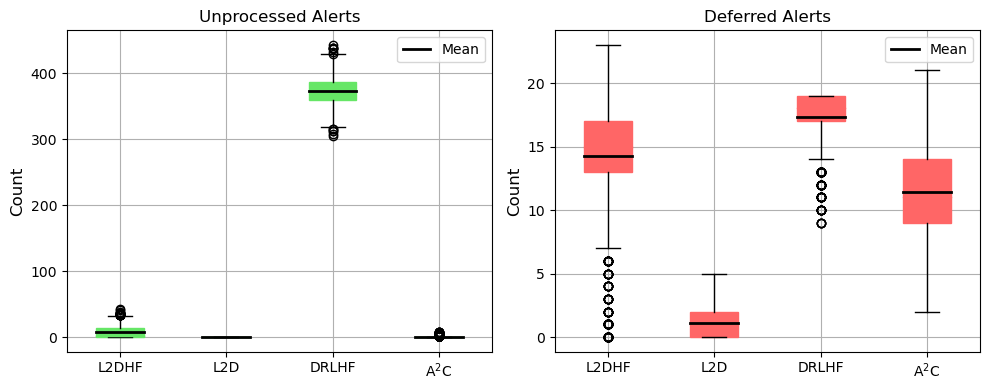

In [23]:
# Add boxplots below the existing plots
fig2, axs2 = plt.subplots(1, 2, figsize=(10, 4))

#unprocessed
data1 = all_Analyst_workload_L2DHF_12PCA_UNSW     # Ranges between 0 and 60
data2 = all_Analyst_workload_L2D_UNSW       # Ranges between 15 and 85
data3 = all_Analyst_workload_DRLHF_12PCA_UNSW         # Ranges between 150 and 580
data4 = all_Analyst_workload_A2C_UNSW 

# Deferred
data5 = deferred_alerts_to_analyst_L2DHF_12PCA_UNSW     # Replace with actual data
data6 = deferred_alerts_to_analyst_L2D_UNSW       # Replace with actual data
data7 = deferred_alerts_to_analyst_DRLHF_12PCA_UNSW     # Replace with actual data
data8 = deferred_alerts_to_analyst_A2C_UNSW       # Replace with actual data

# First boxplot group
box1 = axs2[0].boxplot(
    [data1, data2, data3, data4],
    labels=['L2DHF', 'L2D', 'DRLHF', 'A$^2$C' ],
    patch_artist=True,
    showmeans=True, meanline=True,
    boxprops=dict(facecolor=(0.4, 0.9, 0.4) , color=(0.4, 0.9, 0.4) ),
    meanprops=dict(color='black', linewidth=2, linestyle='-', label='Mean'),
    medianprops=dict(color=(0.4, 0.9, 0.4) )
)
axs2[0].set_title('Unprocessed Alerts', fontsize=12)
axs2[0].set_ylabel('Count', fontsize=12)
axs2[0].grid(True)

# Add legend for the first subplot
mean_line = Line2D([0], [0], color='black', linewidth=2, label='Mean')
axs2[0].legend(handles=[mean_line], loc='upper right', fontsize=10)

# Second boxplot group
box2 = axs2[1].boxplot(
    [data5, data6, data7, data8],
    labels=['L2DHF', 'L2D', 'DRLHF', 'A$^2$C'],
    patch_artist=True,
    showmeans=True, meanline=True,
    boxprops=dict(facecolor=(1.0, 0.4, 0.4), color=(1.0, 0.4, 0.4)),
    meanprops=dict(color='black', linewidth=2, linestyle='-', label='Mean'),
    medianprops=dict(color=(1.0, 0.4, 0.4))
)
axs2[1].set_title('Deferred Alerts', fontsize=12)
axs2[1].set_ylabel('Count', fontsize=12)
axs2[1].grid(True)

# Add legend for the first subplot
mean_line = Line2D([1], [1], color='black', linewidth=2, label='Mean')
axs2[1].legend(handles=[mean_line], loc='upper right', fontsize=10)

# Tight layout
plt.tight_layout()

# Save the plot
# plt.savefig("Unprocessed_deferred_alerts_boxPlot_threeModels_UNSW_12PCA_Poisson.pdf", bbox_inches='tight')
# Show boxplots
plt.show()


In [24]:
import numpy as np

def split_into_segments(data):
    return [
        data[0:500],
        data[500:1000],
        data[1000:1500],
        data[1500:]
    ]

In [25]:
def plot_segmented_boxplots(ax, datasets, title):

    models = ['L2DHF', 'L2D', 'DRLHF', 'A$^2$C']

    segment_color = 'lightblue'
    overall_color = 'lightcoral'

    positions = []
    all_box_data = []

    current_pos = 1

    for data in datasets:

        segments = split_into_segments(data)

        # four segments + overall
        group_data = segments + [data]

        all_box_data.extend(group_data)

        group_positions = np.arange(current_pos,
                                    current_pos + 5)

        positions.extend(group_positions)

        current_pos += 6     # leave gap between models

    bp = ax.boxplot(
        all_box_data,
        positions=positions,
        widths=0.7,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops=dict(
            color='black',
            linewidth=2
        ),
        medianprops=dict(
            color='none',
            linewidth=0
    )
    )

    # colour boxes
    for i, box in enumerate(bp['boxes']):

        if (i + 1) % 5 == 0:
            box.set_facecolor(overall_color)
        else:
            box.set_facecolor(segment_color)

    # --------------------------------------------------
    # connect means for first four segments
    # --------------------------------------------------

    current_pos = 1

    for data in datasets:

        segments = split_into_segments(data)

        means = [np.mean(s) for s in segments]

        x = np.arange(current_pos,
                      current_pos + 4)

        ax.plot(
            x,
            means,
            marker='o',
            linewidth=2,
            color='red'
        )

        current_pos += 6

    # --------------------------------------------------
    # x labels
    # --------------------------------------------------

    model_centres = []

    current_pos = 1

    for _ in models:

        model_centres.append(current_pos + 2)

        current_pos += 6

    ax.set_xticks(model_centres)
    ax.set_xticklabels(models, fontsize=16)

    ax.set_title(title, fontsize=18)

    ax.grid(True, alpha=0.3)

    legend_items = [
        Patch(facecolor=segment_color,
              label='Segments'),
        Patch(facecolor=overall_color,
              label='All time steps'),
        Line2D([0], [0],
               color='red',
               marker='o',
               linewidth=2,
               label='Mean trend')
    ]

    ax.legend(handles=legend_items,
              loc='upper right', fontsize=14)

In [27]:
#unprocessed
data1 = all_Analyst_workload_L2DHF_12PCA_UNSW     
data2 = all_Analyst_workload_L2D_UNSW       
data3 = all_Analyst_workload_DRLHF_12PCA_UNSW        
data4 = all_Analyst_workload_A2C_UNSW 

# Deferred
data5 = deferred_alerts_to_analyst_L2DHF_12PCA_UNSW     
data6 = deferred_alerts_to_analyst_L2D_UNSW       
data7 = deferred_alerts_to_analyst_DRLHF_12PCA_UNSW     
data8 = deferred_alerts_to_analyst_A2C_UNSW       

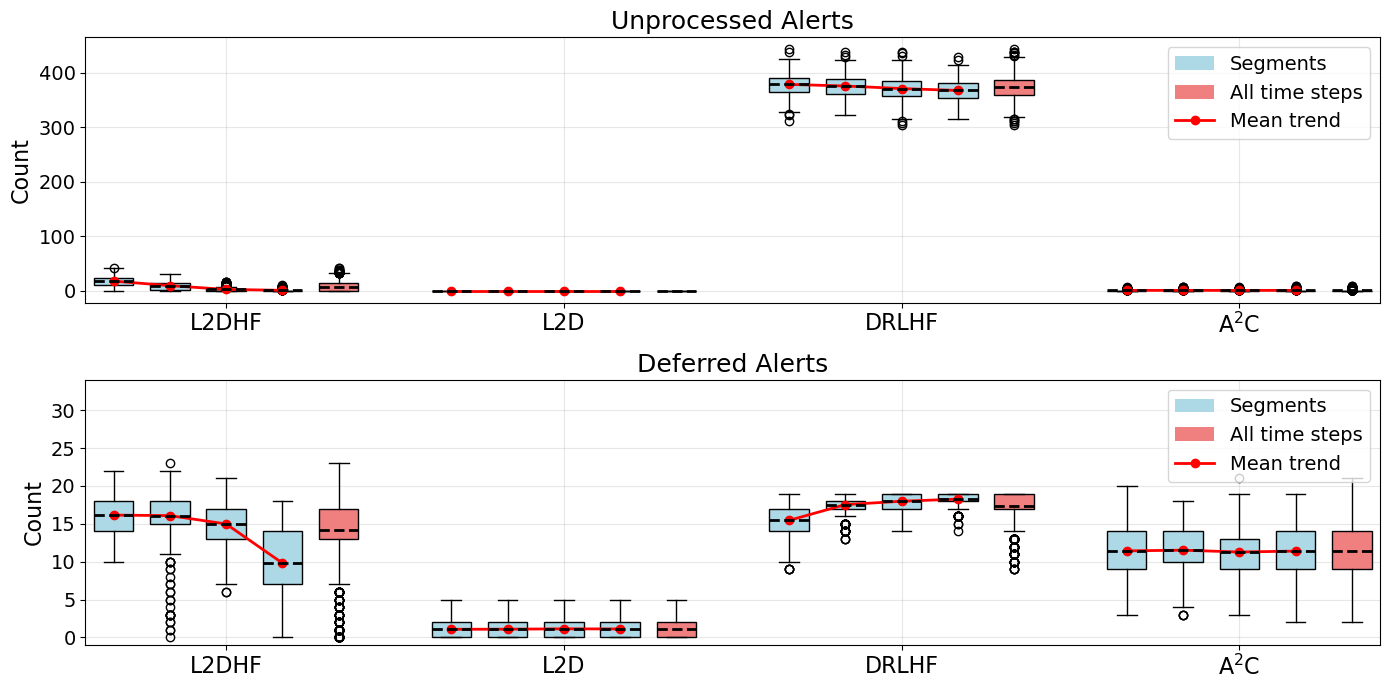

In [28]:
fig2, axs2 = plt.subplots(
    2,
    1,
    figsize=(14,7)
)

plot_segmented_boxplots(
    axs2[0],
    [
        data1,
        data2,
        data3,
        data4
    ],
    'Unprocessed Alerts'
)

plot_segmented_boxplots(
    axs2[1],
    [
        data5,
        data6,
        data7,
        data8
    ],
    'Deferred Alerts'
)

axs2[0].set_ylabel('Count', fontsize=16)
axs2[1].set_ylabel('Count', fontsize=16)

axs2[0].tick_params(axis='y', labelsize=14)
axs2[1].tick_params(axis='y', labelsize=14)

axs2[1].set_ylim(-1, 34)
axs2[1].set_yticks(np.arange(0, 34, 5))

plt.tight_layout()
# Save the plot
# plt.savefig("Unprocessed_deferred_alerts_UNSW.pdf", bbox_inches='tight')

plt.show()

In [29]:
#unprocessed
data1 = all_Analyst_workload_L2DHF_12PCA_UNSW     
data2 = all_Analyst_workload_L2D_UNSW      
data3 = all_Analyst_workload_DRLHF_12PCA_UNSW         
data4 = all_Analyst_workload_A2C_UNSW 

# Deferred
data5 = deferred_alerts_to_analyst_L2DHF_12PCA_UNSW     
data6 = deferred_alerts_to_analyst_L2D_UNSW       
data7 = deferred_alerts_to_analyst_DRLHF_12PCA_UNSW     
data8 = deferred_alerts_to_analyst_A2C_UNSW       

# Remaining time

data9 = all_Remaining_time_L2DHF_12PCA_UNSW    
data10 = all_Remaining_time_L2D_UNSW       
data11 = all_Remaining_time_DRLHF_12PCA_UNSW     
data12 = all_Remaining_time_A2C_UNSW        

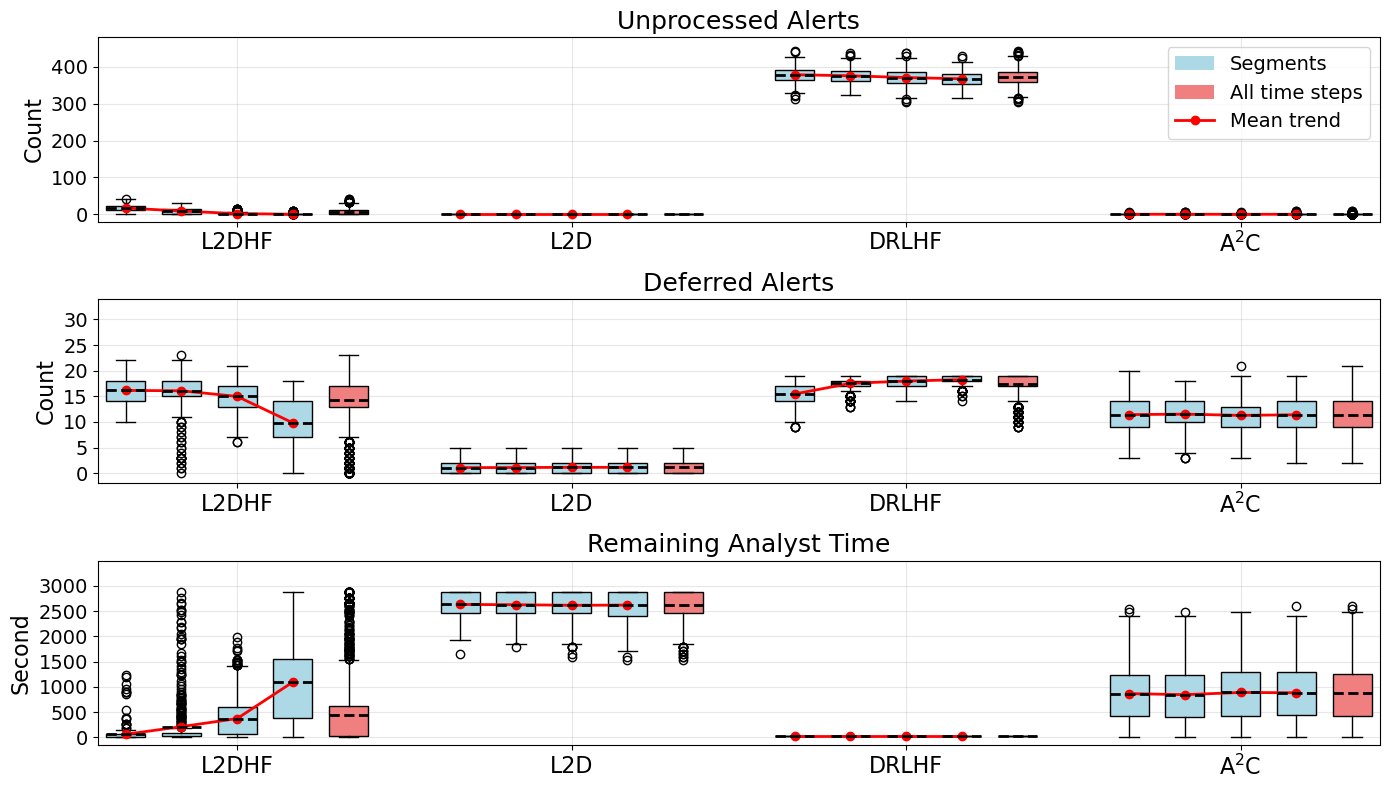

In [30]:
fig2, axs2 = plt.subplots(
    3,
    1,
    figsize=(14,8)
)

plot_segmented_boxplots(
    axs2[0],
    [
        data1,
        data2,
        data3,
        data4
    ],
    'Unprocessed Alerts'
)

plot_segmented_boxplots(
    axs2[1],
    [
        data5,
        data6,
        data7,
        data8
    ],
    'Deferred Alerts'
)

plot_segmented_boxplots(
    axs2[2],
    [
        data9,
        data10,
        data11,
        data12
    ],
    'Remaining Analyst Time'
)

axs2[0].set_ylabel('Count', fontsize=16)
axs2[1].set_ylabel('Count', fontsize=16)
axs2[2].set_ylabel('Second', fontsize=16)

axs2[0].tick_params(axis='y', labelsize=14)
axs2[1].tick_params(axis='y', labelsize=14)
axs2[2].tick_params(axis='y', labelsize=14)

axs2[0].set_ylim(-20, 480)
axs2[0].set_yticks(np.arange(0, 480, 100))

axs2[1].set_ylim(-2, 34)
axs2[1].set_yticks(np.arange(0, 34, 5))

axs2[2].set_ylim(-150, 3500)
axs2[2].set_yticks(np.arange(0, 3500, 500))

axs2[1].get_legend().remove()
axs2[2].get_legend().remove()

plt.tight_layout()
# Save the plot
# plt.savefig("Unprocessed_deferred_remainingTime_alerts_UNSW.pdf", bbox_inches='tight')

plt.show()

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For cost metrics as 1) unprocessed alert, and 2) deferred alerts 3) Execution time (the lower, the better):
# x: model (baselines, SOTA)
# y: L2DHF

In [ ]:
#unprocessed
# all_Analyst_workload_L2DHF_12PCA_UNSW     
# all_Analyst_workload_L2D_UNSW       
# all_Analyst_workload_DRLHF_12PCA_UNSW         
# all_Analyst_workload_A2C_UNSW 

# Deferred
# deferred_alerts_to_analyst_L2DHF_12PCA_UNSW     
# deferred_alerts_to_analyst_L2D_UNSW       
# deferred_alerts_to_analyst_DRLHF_12PCA_UNSW     
# deferred_alerts_to_analyst_A2C_UNSW       

In [ ]:
# P_value, Effect size, CI (uprocessed alerts, deferred alerts)

In [ ]:
#unprocessed

In [ ]:
unprocessed_results = []

In [ ]:
# unprocessed # L2D
x = all_Analyst_workload_L2D_UNSW
y = all_Analyst_workload_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

unprocessed_results.append({
    "Model": "L2D",
    "Type": "Unprocessed",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(unprocessed_results[0])


In [ ]:
# unprocessed # DRLHF
x = all_Analyst_workload_DRLHF_12PCA_UNSW
y = all_Analyst_workload_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

unprocessed_results.append({
    "Model": "DRLHF",
    "Type": "Unprocessed",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(unprocessed_results[1])

In [ ]:
# unprocessed # A2C
x = all_Analyst_workload_A2C_UNSW
y = all_Analyst_workload_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

unprocessed_results.append({
    "Model": "A2C",
    "Type": "Unprocessed",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(unprocessed_results[2])

In [ ]:
# deferred

In [ ]:
deferred_results = []

In [ ]:
# deferred_alerts_to_analyst_L2DHF_12PCA_UNSW     
# deferred_alerts_to_analyst_L2D_UNSW       
# deferred_alerts_to_analyst_DRLHF_12PCA_UNSW     
# deferred_alerts_to_analyst_A2C_UNSW  

In [ ]:
# deferred # L2D
x = deferred_alerts_to_analyst_L2D_UNSW
y = deferred_alerts_to_analyst_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

deferred_results.append({
    "Model": "L2D",
    "Type": "Deferred",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(deferred_results[0])


In [ ]:
# deferred # DRLHF
x = deferred_alerts_to_analyst_DRLHF_12PCA_UNSW 
y = deferred_alerts_to_analyst_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

deferred_results.append({
    "Model": "DRLHF",
    "Type": "Deferred",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(deferred_results[1])

In [ ]:
# deferred # A2C
x = deferred_alerts_to_analyst_A2C_UNSW
y = deferred_alerts_to_analyst_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

deferred_results.append({
    "Model": "A2C",
    "Type": "Deferred",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(deferred_results[2])

In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For remaining_analyst_time which is a benefit metric (the higher, the better):
# x: L2DHF 
# y: model (baselines, SOTA)

In [ ]:
# remaining analyst time

In [31]:
remaining_analyst_time = []

In [ ]:
# Remaining time
# all_Remaining_time_L2DHF_12PCA_UNSW     
# all_Remaining_time_L2D_UNSW       
# all_Remaining_time_DRLHF_12PCA_UNSW    
# all_Remaining_time_A2C_UNSW        

In [32]:
# remaining_analyst_time # L2D
x = all_Remaining_time_L2DHF_12PCA_UNSW 
y = all_Remaining_time_L2D_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

remaining_analyst_time.append({
    "Model": "L2D",
    "Type": "remaining_analyst_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(remaining_analyst_time[0])


{'Model': 'L2D', 'Type': 'remaining_analyst_time', 'P_value': 0.0, 'Effect_size': -0.941586110717435, 'CI_Lower': -0.95, 'CI_Upper': -0.93}


In [33]:
# remaining_analyst_time # DRLHF
x = all_Remaining_time_L2DHF_12PCA_UNSW
y = all_Remaining_time_DRLHF_12PCA_UNSW
stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

remaining_analyst_time.append({
    "Model": "DRLHF",
    "Type": "remaining_analyst_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(remaining_analyst_time[1])

{'Model': 'DRLHF', 'Type': 'remaining_analyst_time', 'P_value': 3.7595658293129045e-241, 'Effect_size': 0.5421626984126984, 'CI_Lower': 0.51, 'CI_Upper': 0.57}


In [34]:
# remaining_analyst_time # A2C
x = all_Remaining_time_L2DHF_12PCA_UNSW
y = all_Remaining_time_A2C_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

remaining_analyst_time.append({
    "Model": "A2C",
    "Type": "remaining_analyst_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(remaining_analyst_time[2])

{'Model': 'A2C', 'Type': 'remaining_analyst_time', 'P_value': 1.3480757812443258e-169, 'Effect_size': -0.5041633696302594, 'CI_Lower': -0.54, 'CI_Upper': -0.47}


In [35]:
data = remaining_analyst_time

with open('remaining_analyst_time_UNSW.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [ ]:
# Execution time

In [ ]:
# UNSW

In [36]:
with open('all_time_step_execution_time_L2DHF_12PCA_UNSW.json', 'r') as file:
    all_time_step_execution_time_L2DHF_12PCA_UNSW = json.load(file)

In [37]:
with open('all_time_step_execution_time_L2D_UNSW.json', 'r') as file:
    all_time_step_execution_time_L2D_UNSW = json.load(file)

In [38]:
with open('all_time_step_execution_time_DRLHF_12PCA_UNSW.json', 'r') as file:
    all_time_step_execution_time_DRLHF_12PCA_UNSW = json.load(file)

In [39]:
with open('all_time_step_execution_time_Active_Learning_UNSW.json', 'r') as file:
    all_time_step_execution_time_Active_Learning_UNSW = json.load(file)

In [40]:
with open('all_time_step_execution_time_A2C_UNSW.json', 'r') as file:
    all_time_step_execution_time_A2C_UNSW = json.load(file)

In [ ]:
# CICIDS2017

In [41]:
with open('all_time_step_execution_time_L2DHF_6PCA_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_L2DHF_6PCA_CICIDS2017 = json.load(file)

In [42]:
with open('all_time_step_execution_time_L2D_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_L2D_CICIDS2017 = json.load(file)

In [43]:
with open('all_time_step_execution_time_DRLHF_6PCA_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_DRLHF_6PCA_CICIDS2017 = json.load(file)

In [44]:
with open('all_time_step_execution_time_Active_Learning_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_Active_Learning_CICIDS2017 = json.load(file)

In [45]:
with open('all_time_step_execution_time_A2C_CICIDS2017.json', 'r') as file:
    all_time_step_execution_time_A2C_CICIDS2017 = json.load(file)

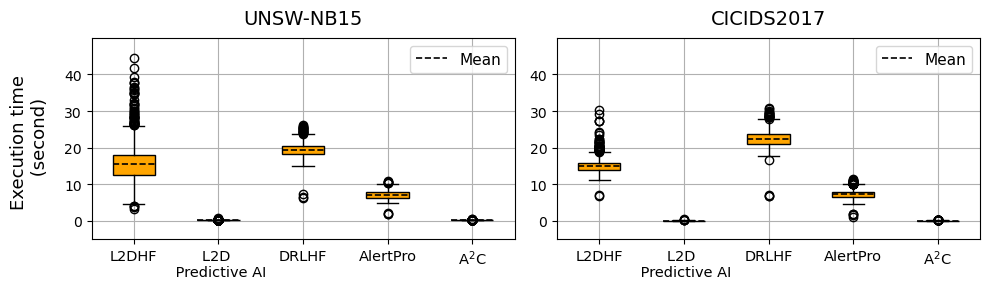

In [60]:
data_UNSW = [all_time_step_execution_time_L2DHF_12PCA_UNSW,
             all_time_step_execution_time_L2D_UNSW,
             all_time_step_execution_time_DRLHF_12PCA_UNSW, 
             all_time_step_execution_time_Active_Learning_UNSW,
             all_time_step_execution_time_A2C_UNSW]
labels_UNSW = ['L2DHF', 'L2D \n Predictive AI', 'DRLHF', 'AlertPro', 'A$^2$C']

data_CIC = [all_time_step_execution_time_L2DHF_6PCA_CICIDS2017, 
            all_time_step_execution_time_L2D_CICIDS2017, 
            all_time_step_execution_time_DRLHF_6PCA_CICIDS2017,
            all_time_step_execution_time_Active_Learning_CICIDS2017,
            all_time_step_execution_time_A2C_CICIDS2017]
labels_CIC = ['L2DHF', 'L2D \n Predictive AI', 'DRLHF', 'AlertPro', 'A$^2$C']


# Create figure and subplots with specific figure size
fig, axs = plt.subplots(1, 2, figsize=(10, 3), sharex=True)  # 4 rows, 1 column, shared x-axis

# Plot each dataset on its own subplot
axs[0].boxplot(data_UNSW, positions=[1, 2, 3, 4, 5], patch_artist=True,
            showmeans=True, meanline=True,
            boxprops=dict(facecolor='orange', color='black'),
            meanprops=dict(color='black', linewidth=1.2, linestyle='--'),
            medianprops=dict(color='none', linewidth=0))
axs[0].set_ylabel("Execution time \n (second)", fontsize=13, labelpad=11)
axs[0].set_xticks([1, 2, 3, 4, 5], labels_UNSW, fontsize=10.5)
axs[0].set_ylim(-5, 50)
axs[0].set_yticks(range(0, 50, 10))
axs[0].set_title("UNSW-NB15", fontsize=14, pad=10)
# Add legend for the first subplot
mean_line = Line2D([0], [0], color='black', linewidth=1.2, label='Mean', linestyle='--')
axs[0].legend(handles=[mean_line], loc='upper right', fontsize=11)


# Plot each dataset on its own subplot
axs[1].boxplot(data_CIC, positions=[1, 2, 3, 4, 5], patch_artist=True,
            showmeans=True, meanline=True,
            boxprops=dict(facecolor='orange', color='black'),
            meanprops=dict(color='black', linewidth=1.2, linestyle='--'),
            medianprops=dict(color='none', linewidth=0))
# axs[1].set_ylabel("Execution time \n (seconds)", fontsize=12, labelpad=12)
axs[1].set_xticks([1, 2, 3, 4, 5], labels_CIC, fontsize=10.5)
axs[1].set_ylim(-5, 50)
axs[1].set_yticks(range(0, 50, 10))
axs[1].set_title("CICIDS2017", fontsize=14, pad=10)
axs[1].legend(handles=[mean_line], loc='upper right', fontsize=11)

# Add grid to each subplot
for ax in axs:
    ax.grid(True)

# Adjust layout for better spacing between subplots
plt.tight_layout()

plt.savefig("Execution_time_twoDatasets.pdf", bbox_inches='tight') 

# Show the plot
plt.show()


In [47]:
avg_all_time_step_execution_time_L2DHF_12PCA_UNSW  = sum(all_time_step_execution_time_L2DHF_12PCA_UNSW) / len(all_time_step_execution_time_L2DHF_12PCA_UNSW)

print("Average all_time_step_execution_time_L2DHF_12PCA_UNSW :", avg_all_time_step_execution_time_L2DHF_12PCA_UNSW)

Average all_time_step_execution_time_L2DHF_12PCA_UNSW : 15.44292701851754


In [48]:
avg_all_time_step_execution_time_L2DHF_6PCA_CICIDS2017  = sum(all_time_step_execution_time_L2DHF_6PCA_CICIDS2017) / len(all_time_step_execution_time_L2DHF_6PCA_CICIDS2017)

print("Average all_time_step_execution_time_L2DHF_6PCA_CICIDS2017 :", avg_all_time_step_execution_time_L2DHF_6PCA_CICIDS2017)

Average all_time_step_execution_time_L2DHF_6PCA_CICIDS2017 : 15.02029439913375


In [ ]:
# pingouin.mwu(x, y, alternative='two-sided', **kwargs)
# The rank biserial correlation (RBC) ranges from -1 to 1.
# Negative values indicate that y > x.
# Positive values indicate x > y.
# For cost metrics as 1) unprocessed alert, and 2) deferred alerts 3) Execution time (the lower, the better):
# x: model (baselines, SOTA)
# y: L2DHF

In [ ]:
execution_time_results = []

In [ ]:
# execution_time # L2D
x = all_time_step_execution_time_L2D_UNSW
y = all_time_step_execution_time_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "L2D",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[0])


In [ ]:
# execution_time # DRLHF
x = all_time_step_execution_time_DRLHF_12PCA_UNSW
y = all_time_step_execution_time_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "DRLHF",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[1])

In [ ]:
# execution_time # Active_Learning
x = all_time_step_execution_time_Active_Learning_UNSW
y = all_time_step_execution_time_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "Active_Learning",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[2])

In [ ]:
# execution_time # A2C
x = all_time_step_execution_time_A2C_UNSW
y = all_time_step_execution_time_L2DHF_12PCA_UNSW

stats = mwu_stats(x, y)

P_value = stats['p_val']
Effect_size_point = stats['RBC']

CI_value = Confidence_Interval(x, y)

execution_time_results.append({
    "Model": "A2C",
    "Type": "execution_time",
    "P_value": P_value,
    "Effect_size": Effect_size_point,
    "CI_Lower": CI_value[0],
    "CI_Upper": CI_value[1]
})

print(execution_time_results[3])

In [ ]:
## Processed
Accuracy_Overall_Processed = {'Accuracy_L2DHF':0.998, 
                    'Accuracy_L2D':0.994, 
                    'Accuracy_Predictive_AI':0.993, 
                    'Accuracy_DRLHF':0.934,
                    'Accuracy_AlertPro':0.844,
                    'Accuracy_A2C':0.999}

Accuracy_Without_Normal_Processed = {'Accuracy_L2DHF':0.988, 
                    'Accuracy_L2D':0.947, 
                    'Accuracy_Predictive_AI':0.937, 
                    'Accuracy_DRLHF':0.964,
                    'Accuracy_AlertPro':0.311,
                    'Accuracy_A2C':0.999}

Accuracy_Critical_Processed = {'Accuracy_L2DHF':0.977, 
                    'Accuracy_L2D':0.864, 
                    'Accuracy_Predictive_AI':0.841, 
                    'Accuracy_DRLHF':0.957,
                    'Accuracy_AlertPro':None,
                    'Accuracy_A2C':0.997}

Accuracy_High_Processed = {'Accuracy_L2DHF':0.985, 
                    'Accuracy_L2D':0.944, 
                    'Accuracy_Predictive_AI':0.917, 
                    'Accuracy_DRLHF':0.931,
                    'Accuracy_AlertPro':None,
                    'Accuracy_A2C':1.0}

Accuracy_Medium_Processed = {'Accuracy_L2DHF':0.991, 
                    'Accuracy_L2D':0.959, 
                    'Accuracy_Predictive_AI':0.954, 
                    'Accuracy_DRLHF':0.967,
                    'Accuracy_AlertPro':None,
                    'Accuracy_A2C':0.999}

Accuracy_Low_Processed = {'Accuracy_L2DHF':0.925, 
                    'Accuracy_L2D':0.495, 
                    'Accuracy_Predictive_AI':0.389, 
                    'Accuracy_DRLHF':0.875,
                    'Accuracy_AlertPro':None,
                    'Accuracy_A2C':1.0}

Accuracy_Normal_Processed = {'Accuracy_L2DHF':1.0, 
                    'Accuracy_L2D':1.0, 
                    'Accuracy_Predictive_AI':1.0, 
                    'Accuracy_DRLHF':0.927,
                    'Accuracy_AlertPro':0.910,
                    'Accuracy_A2C':1.0}

## Unprocessed
Accuracy_Overall_Unprocessed = {'Accuracy_L2DHF':0.993,   
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Without_Normal_Unprocessed = {'Accuracy_L2DHF':0.937, 
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Critical_Unprocessed = {'Accuracy_L2DHF':0.841,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_High_Unprocessed = {'Accuracy_L2DHF':0.917,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Medium_Unprocessed = {'Accuracy_L2DHF':0.954,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Low_Unprocessed = {'Accuracy_L2DHF':0.389,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Normal_Unprocessed = {'Accuracy_L2DHF':1.0, 
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}



In [ ]:
Accuracy_Overall_Unprocessed = {'Accuracy_L2DHF':0.993,   
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Without_Normal_Unprocessed = {'Accuracy_L2DHF':0.937, 
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Critical_Unprocessed = {'Accuracy_L2DHF':0.841,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_High_Unprocessed = {'Accuracy_L2DHF':0.917,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Medium_Unprocessed = {'Accuracy_L2DHF':0.954,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Low_Unprocessed = {'Accuracy_L2DHF':0.389,  
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}

Accuracy_Normal_Unprocessed = {'Accuracy_L2DHF':1.0, 
                    'Accuracy_DRLHF':0.0,
                    'Accuracy_A2C':0.0}


In [ ]:
# Effect size function (cohens_d)

def cohens_d(x1, x2):
    """
    Compute Cohen's d for independent samples using pooled standard deviation.

    Parameters:
    x1, x2 : array-like (can contain None or np.nan)

    Returns:
    Cohen's d (float)
    """

    # convert to numpy arrays and remove None/NaN
    x1 = np.array(x1, dtype=float)
    x2 = np.array(x2, dtype=float)

    x1 = x1[~np.isnan(x1)]
    x2 = x2[~np.isnan(x2)]

    n1 = len(x1)
    n2 = len(x2)

    if n1 < 2 or n2 < 2:
        return np.nan

    # means
    mean1 = np.mean(x1)
    mean2 = np.mean(x2)

    # standard deviations
    s1 = np.std(x1, ddof=1)
    s2 = np.std(x2, ddof=1)

    # pooled standard deviation (from your formula)
    pooled_std = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
    )

    if pooled_std == 0:
        return np.nan

    # Cohen's d
    d = (mean1 - mean2) / pooled_std

    return d

In [ ]:
# P_values overall